# 13 - Per-Class Accuracy Analysis

**Extends Phase 2, Step 2.5 - Model Comparison & Selection**

Breaks down each of the 4 classifiers' performance **class-by-class** (not just the single overall test accuracy number), and renders a confusion matrix per model so you can see exactly which of the 25 classes each model handles well and which it confuses with which.

This notebook re-uses the confusion matrix and class list already saved in `outputs/metrics_<model>.json` by notebooks 05-08 - **no model reloading or re-prediction needed**, so it runs in seconds even on CPU.

### 1. Install dependencies and mount Drive

In [1]:
!pip install -q pandas matplotlib numpy


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


### 2. Project configuration

In [3]:
import os

# ---------------------------------------------------------------------------
# Project configuration - matches every other SmartVision AI notebook.
# ---------------------------------------------------------------------------
BASE_DIR = "/content/drive/MyDrive/SmartVisionAI"

MODELS_DIR = os.path.join(BASE_DIR, "models")
OUTPUTS_DIR = os.path.join(BASE_DIR, "outputs")

SELECTED_CLASSES = [
    # Vehicles (6)
    "car", "truck", "bus", "motorcycle", "bicycle", "airplane",
    # Person (1)
    "person",
    # Outdoor (3)
    "traffic light", "stop sign", "bench",
    # Animals (6)
    "dog", "cat", "horse", "bird", "cow", "elephant",
    # Kitchen & food (5)
    "bottle", "cup", "bowl", "pizza", "cake",
    # Furniture & indoor (4)
    "chair", "couch", "bed", "potted plant",
]
assert len(SELECTED_CLASSES) == 25

def safe_name(class_name):
    return class_name.replace(" ", "_")

def display_name(safe_class_name):
    return safe_class_name.replace("_", " ")

MODEL_KEYS = ["vgg16", "resnet50", "mobilenetv2", "efficientnetb0"]
MODEL_DISPLAY_NAMES = {
    "vgg16": "VGG16",
    "resnet50": "ResNet50",
    "mobilenetv2": "MobileNetV2",
    "efficientnetb0": "EfficientNetB0",
}

print("BASE_DIR:", BASE_DIR)


BASE_DIR: /content/drive/MyDrive/SmartVisionAI


### 3. Load all 4 models' saved metrics (confusion matrix + class names)

Run notebooks 05-08 first if any of these are missing.

In [4]:
import json

all_metrics = {}
for key in MODEL_KEYS:
    path = os.path.join(OUTPUTS_DIR, f"metrics_{key}.json")
    if os.path.exists(path):
        with open(path) as f:
            all_metrics[key] = json.load(f)
    else:
        print(f"WARNING: {path} not found - train that model first (notebooks 05-08).")

print(f"Loaded metrics for: {list(all_metrics.keys())}")

# Sanity check: every model's confusion matrix should use the same class
# ordering (all 4 were built from the same classification/ directory
# structure), otherwise per-class comparison across models would be wrong.
reference_classes = None
for key, m in all_metrics.items():
    if reference_classes is None:
        reference_classes = m["class_names"]
    elif m["class_names"] != reference_classes:
        raise ValueError(
            f"{key}'s class ordering doesn't match the other models - "
            "per-class comparison would be misaligned. This shouldn't "
            "happen if all 4 were trained on the same classification/ folder."
        )
print("Class ordering confirmed consistent across all loaded models.")
print("Classes (folder order):", reference_classes)


Loaded metrics for: ['vgg16', 'resnet50', 'mobilenetv2', 'efficientnetb0']
Class ordering confirmed consistent across all loaded models.
Classes (folder order): ['airplane', 'bed', 'bench', 'bicycle', 'bird', 'bottle', 'bowl', 'bus', 'cake', 'car', 'cat', 'chair', 'couch', 'cow', 'cup', 'dog', 'elephant', 'horse', 'motorcycle', 'person', 'pizza', 'potted_plant', 'stop_sign', 'traffic_light', 'truck']


### 4. Compute per-class accuracy (recall) for every model

Per-class accuracy here means **recall**: of all the true test examples belonging to a class, what fraction did the model correctly identify? This is exactly the diagonal of the confusion matrix divided by that row's total.

In [5]:
import numpy as np
import pandas as pd

per_class_accuracy = {}  # key -> {class_name: accuracy}

for key, m in all_metrics.items():
    cm = np.array(m["confusion_matrix"])
    class_names = m["class_names"]
    row_totals = cm.sum(axis=1)
    with np.errstate(divide="ignore", invalid="ignore"):
        recall_per_class = np.where(row_totals > 0, np.diag(cm) / row_totals, np.nan)
    per_class_accuracy[key] = dict(zip(class_names, recall_per_class))

# Combine into one table: rows = classes (nice display names), columns = models
table_rows = []
for cname in reference_classes:
    row = {"class": display_name(cname)}
    for key in all_metrics.keys():
        row[MODEL_DISPLAY_NAMES[key]] = per_class_accuracy[key][cname]
    table_rows.append(row)

df = pd.DataFrame(table_rows).set_index("class")
df["Average"] = df.mean(axis=1)
df_sorted = df.sort_values("Average", ascending=False)

pd.set_option("display.float_format", lambda x: f"{x*100:.1f}%")
df_sorted


,VGG16,ResNet50,MobileNetV2,EfficientNetB0,Average
class,,,,,
elephant,92.6%,92.6%,92.6%,92.6%,92.6%
stop sign,85.2%,90.7%,81.5%,94.4%,88.0%
pizza,81.1%,84.9%,83.0%,84.9%,83.5%
cat,87.0%,77.8%,81.5%,83.3%,82.4%
couch,81.5%,88.9%,77.8%,75.9%,81.0%
traffic light,70.4%,90.7%,75.9%,87.0%,81.0%
cow,61.1%,74.1%,72.2%,87.0%,73.6%
cake,67.9%,83.0%,56.6%,86.8%,73.6%
bicycle,64.8%,74.1%,74.1%,77.8%,72.7%


### 5. Save the per-class accuracy table

In [6]:
csv_path = os.path.join(OUTPUTS_DIR, "per_class_accuracy.csv")
df_sorted.to_csv(csv_path)
print(f"Saved: {csv_path}")


Saved: /content/drive/MyDrive/SmartVisionAI/outputs/per_class_accuracy.csv


### 6. Best and worst classes - per model and overall

Directly answers "which class has the best accuracy" for each model, and overall (averaged across all 4).

In [7]:
print("Best and worst class per model:\n")
for key in all_metrics.keys():
    col = MODEL_DISPLAY_NAMES[key]
    best_class = df[col].idxmax()
    worst_class = df[col].idxmin()
    print(f"{col:<15} best: {best_class:<15} ({df[col][best_class]*100:.1f}%)   "
          f"worst: {worst_class:<15} ({df[col][worst_class]*100:.1f}%)")

print("\nOverall (averaged across all 4 models):")
print(f"  Best class:  {df_sorted.index[0]}  ({df_sorted['Average'].iloc[0]*100:.1f}%)")
print(f"  Worst class: {df_sorted.index[-1]}  ({df_sorted['Average'].iloc[-1]*100:.1f}%)")

print("\nTop 5 best-performing classes overall:")
print(df_sorted["Average"].head(5).apply(lambda x: f"{x*100:.1f}%"))

print("\nBottom 5 worst-performing classes overall:")
print(df_sorted["Average"].tail(5).apply(lambda x: f"{x*100:.1f}%"))


Best and worst class per model:

VGG16           best: elephant        (92.6%)   worst: car             (24.1%)
ResNet50        best: elephant        (92.6%)   worst: bed             (41.5%)
MobileNetV2     best: elephant        (92.6%)   worst: car             (20.4%)
EfficientNetB0  best: stop sign       (94.4%)   worst: car             (48.1%)

Overall (averaged across all 4 models):
  Best class:  elephant  (92.6%)
  Worst class: car  (37.5%)

Top 5 best-performing classes overall:
class
elephant     92.6%
stop sign    88.0%
pizza        83.5%
cat          82.4%
couch        81.0%
Name: Average, dtype: object

Bottom 5 worst-performing classes overall:
class
cup       63.9%
person    50.5%
bed       49.5%
chair     47.7%
car       37.5%
Name: Average, dtype: object


### 7. Per-class accuracy heatmap (all 4 models side by side)

One glance at which classes are strong/weak across every model at once.

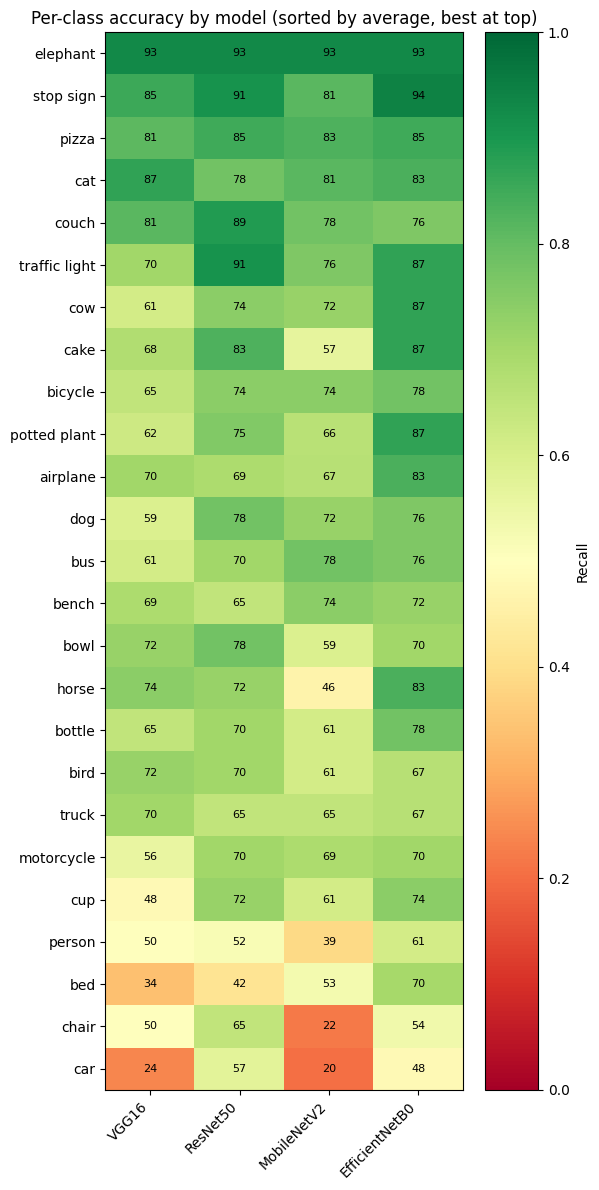

In [8]:
import matplotlib.pyplot as plt

model_cols = [MODEL_DISPLAY_NAMES[k] for k in all_metrics.keys()]
heat_data = df_sorted[model_cols].values

fig, ax = plt.subplots(figsize=(6, 12))
im = ax.imshow(heat_data, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(model_cols)))
ax.set_xticklabels(model_cols, rotation=45, ha="right")
ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels(df_sorted.index)
for i in range(heat_data.shape[0]):
    for j in range(heat_data.shape[1]):
        val = heat_data[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val*100:.0f}", ha="center", va="center", fontsize=8)
ax.set_title("Per-class accuracy by model (sorted by average, best at top)")
fig.colorbar(im, ax=ax, label="Recall")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "per_class_accuracy_heatmap.png"), dpi=150)
plt.show()


### 8. Confusion matrix for each model

Shows not just per-class accuracy but exactly **which other class each model confuses it with** - the off-diagonal cells.

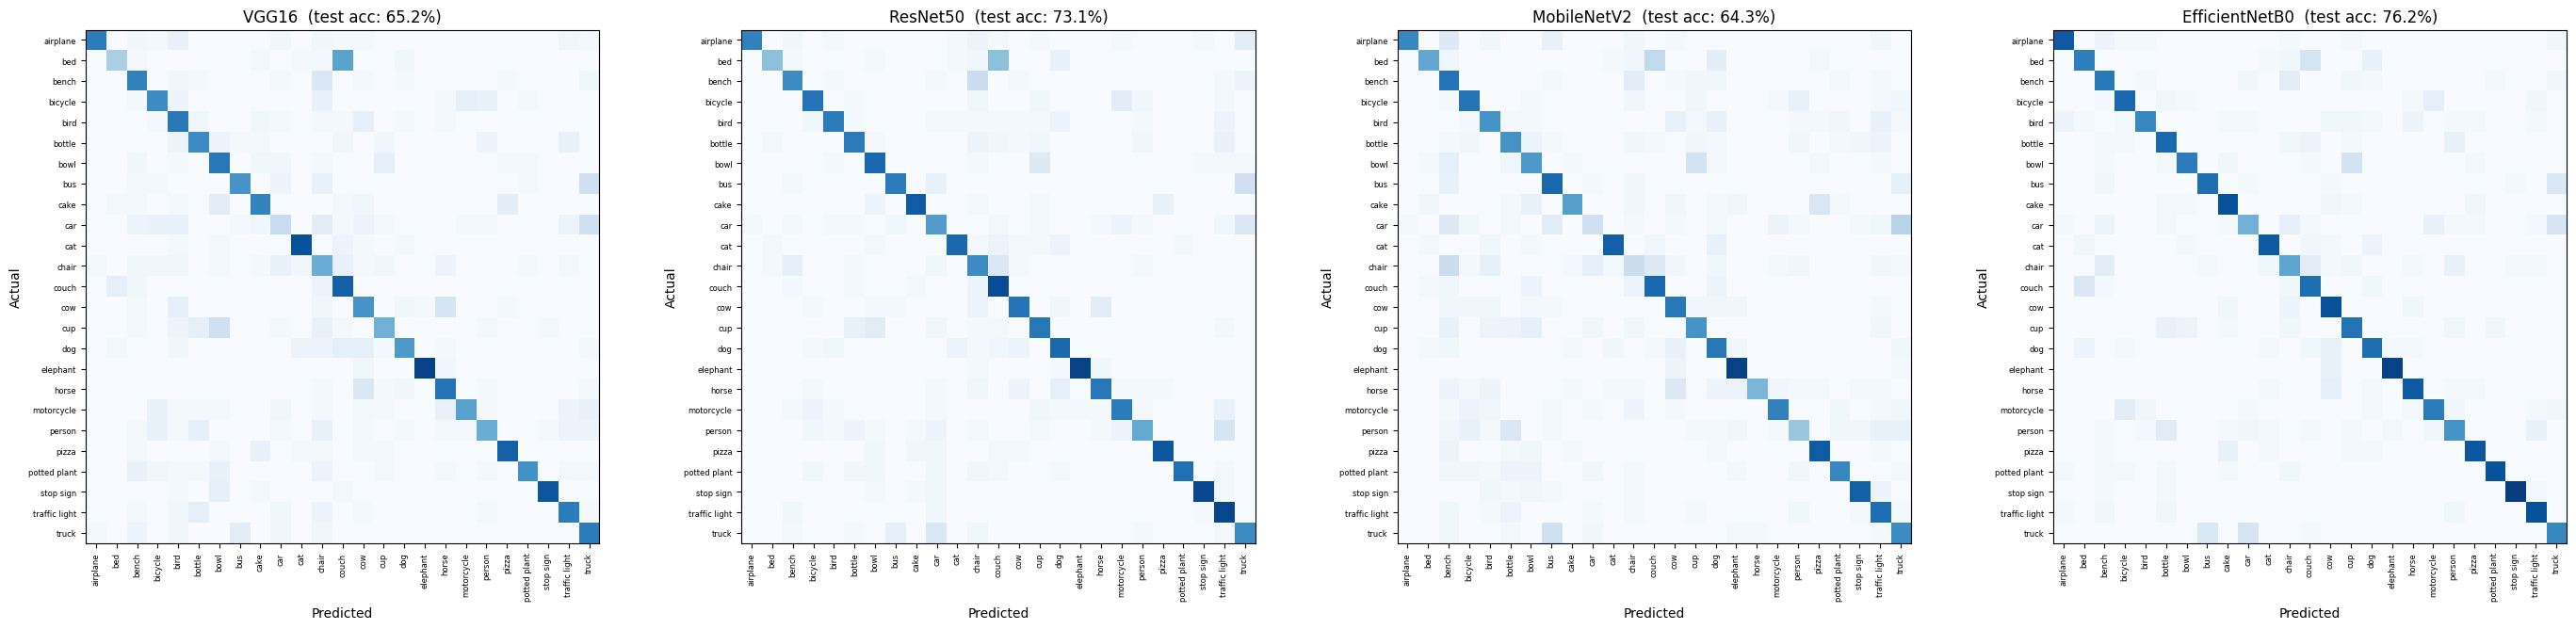

In [9]:
n_models = len(all_metrics)
fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 6.5))
if n_models == 1:
    axes = [axes]

for ax, (key, m) in zip(axes, all_metrics.items()):
    cm = np.array(m["confusion_matrix"])
    row_totals = cm.sum(axis=1, keepdims=True)
    with np.errstate(divide="ignore", invalid="ignore"):
        cm_normalized = np.where(row_totals > 0, cm / row_totals, 0)

    im = ax.imshow(cm_normalized, cmap="Blues", vmin=0, vmax=1)
    class_labels = [display_name(c) for c in m["class_names"]]
    ax.set_xticks(range(len(class_labels)))
    ax.set_xticklabels(class_labels, rotation=90, fontsize=6)
    ax.set_yticks(range(len(class_labels)))
    ax.set_yticklabels(class_labels, fontsize=6)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{MODEL_DISPLAY_NAMES[key]}  (test acc: {m['test_accuracy']*100:.1f}%)")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "confusion_matrices_per_class.png"), dpi=150)
plt.show()


### 9. Biggest confusions - what each model mistakes each class for

For every class, finds the single most common *wrong* prediction (the largest off-diagonal value in that row) - useful for understanding *why* a class scores low, not just that it does.

In [10]:
print("Biggest single confusion per class (for the best overall model):\n")

best_model_key = df_sorted.columns[0] if False else max(
    all_metrics.keys(), key=lambda k: all_metrics[k]["test_accuracy"]
)
cm = np.array(all_metrics[best_model_key]["confusion_matrix"])
class_names = all_metrics[best_model_key]["class_names"]
print(f"(Using {MODEL_DISPLAY_NAMES[best_model_key]}, the highest-accuracy model)\n")

for i, true_class in enumerate(class_names):
    row = cm[i].copy()
    total = row.sum()
    if total == 0:
        continue
    correct = row[i]
    row[i] = -1  # exclude the diagonal when finding the top confusion
    confused_with_idx = int(np.argmax(row))
    confused_count = row[confused_with_idx]
    if confused_count <= 0:
        continue
    print(
        f"{display_name(true_class):<15} -> most often confused with "
        f"{display_name(class_names[confused_with_idx]):<15} "
        f"({confused_count}/{total} test examples, {correct}/{total} correct)"
    )


Biggest single confusion per class (for the best overall model):

(Using EfficientNetB0, the highest-accuracy model)

airplane        -> most often confused with bench           (3/54 test examples, 45/54 correct)
bed             -> most often confused with couch           (9/53 test examples, 37/53 correct)
bench           -> most often confused with chair           (6/54 test examples, 39/54 correct)
bicycle         -> most often confused with motorcycle      (5/54 test examples, 42/54 correct)
bird            -> most often confused with airplane        (3/54 test examples, 36/54 correct)
bottle          -> most often confused with person          (4/54 test examples, 42/54 correct)
bowl            -> most often confused with cup             (10/54 test examples, 38/54 correct)
bus             -> most often confused with truck           (8/54 test examples, 41/54 correct)
cake            -> most often confused with cow             (2/53 test examples, 46/53 correct)
car             -

### Summary

- `outputs/per_class_accuracy.csv` - full per-class, per-model accuracy table
- `outputs/per_class_accuracy_heatmap.png` - visual summary across all models
- `outputs/confusion_matrices_per_class.png` - one confusion matrix per model

Use the best/worst class printout above (Section 6) to identify which categories might benefit from more training images or augmentation in a future iteration.